In [82]:
# Resumo de todos os resultados
print("\n" + "="*70)
print(" RESUMO COMPARATIVO DE TODOS OS MODELOS")
print("="*70)

# Coletar todos os resultados
all_models_results = []

# Resultados do Grid Search
for r in all_results:
    all_models_results.append({
        'Modelo': f"SVM ({r['Config'][:30]}...)",
        'Accuracy': r['Accuracy'],
        'F1-Score': r['F1']
    })

# Resultados dos classificadores individuais
for r in classifier_results:
    all_models_results.append({
        'Modelo': r['name'],
        'Accuracy': r['accuracy'],
        'F1-Score': f1_score(y_test, r['model'].predict(X_test_best), average='weighted', zero_division=0)
    })

# Resultados do Ensemble
all_models_results.append({
    'Modelo': 'Stacking (Top 3)',
    'Accuracy': acc_stacking,
    'F1-Score': f1_score(y_test, y_pred_stacking, average='weighted', zero_division=0)
})
all_models_results.append({
    'Modelo': 'Soft Voting',
    'Accuracy': acc_voting,
    'F1-Score': f1_score(y_test, y_pred_voting, average='weighted', zero_division=0)
})

# Criar DataFrame e ordenar
results_summary = pd.DataFrame(all_models_results)
results_summary = results_summary.sort_values('Accuracy', ascending=False)
results_summary['Accuracy'] = results_summary['Accuracy'].apply(lambda x: f"{x:.4f} ({x*100:.2f}%)")
results_summary['F1-Score'] = results_summary['F1-Score'].apply(lambda x: f"{x:.4f}")

print("\n" + results_summary.to_string(index=False))

# Comparação com baseline
best_accuracy = max([r['accuracy'] if 'accuracy' in r else r['Accuracy']
                     for r in classifier_results + [{'accuracy': acc_stacking}, {'accuracy': acc_voting}]])

print(f"\n{'='*70}")
print(f" MELHOR RESULTADO: {best_accuracy*100:.2f}%")
print(f" BASELINE (Malcher & Guedes, 2022): {BASELINE*100:.2f}%")
print(f" DIFERENÇA: {(best_accuracy - BASELINE)*100:.2f} pontos percentuais")
print(f"{'='*70}")


 RESUMO COMPARATIVO DE TODOS OS MODELOS

                                 Modelo        Accuracy F1-Score
                       Stacking (Top 3) 0.7714 (77.14%)   0.7715
                            Soft Voting 0.7643 (76.43%)   0.7628
SVM (Fused (Inception+VGG16+Efficie...) 0.7571 (75.71%)   0.7612
                                SVM_RBF 0.7536 (75.36%)   0.7556
              SVM (Fused + PCA(700)...) 0.7500 (75.00%)   0.7546
                             SVM_Linear 0.7429 (74.29%)   0.7464
                           RandomForest 0.7000 (70.00%)   0.6933
                               SVM_Poly 0.5571 (55.71%)   0.5876

 MELHOR RESULTADO: 77.14%
 BASELINE (Malcher & Guedes, 2022): 89.79%
 DIFERENÇA: -12.65 pontos percentuais



 MATRIZES DE CONFUSÃO - TOP 3 MODELOS

TOP 3 MODELOS:
1º Stacking — Acurácia: 77.14%
2º Soft Voting — Acurácia: 76.43%
3º SVM_RBF — Acurácia: 75.36%

------------------------------------------------------------
Matriz de Confusão — Stacking
------------------------------------------------------------

------------------------------------------------------------
Matriz de Confusão — Soft Voting
------------------------------------------------------------

------------------------------------------------------------
Matriz de Confusão — SVM_RBF
------------------------------------------------------------


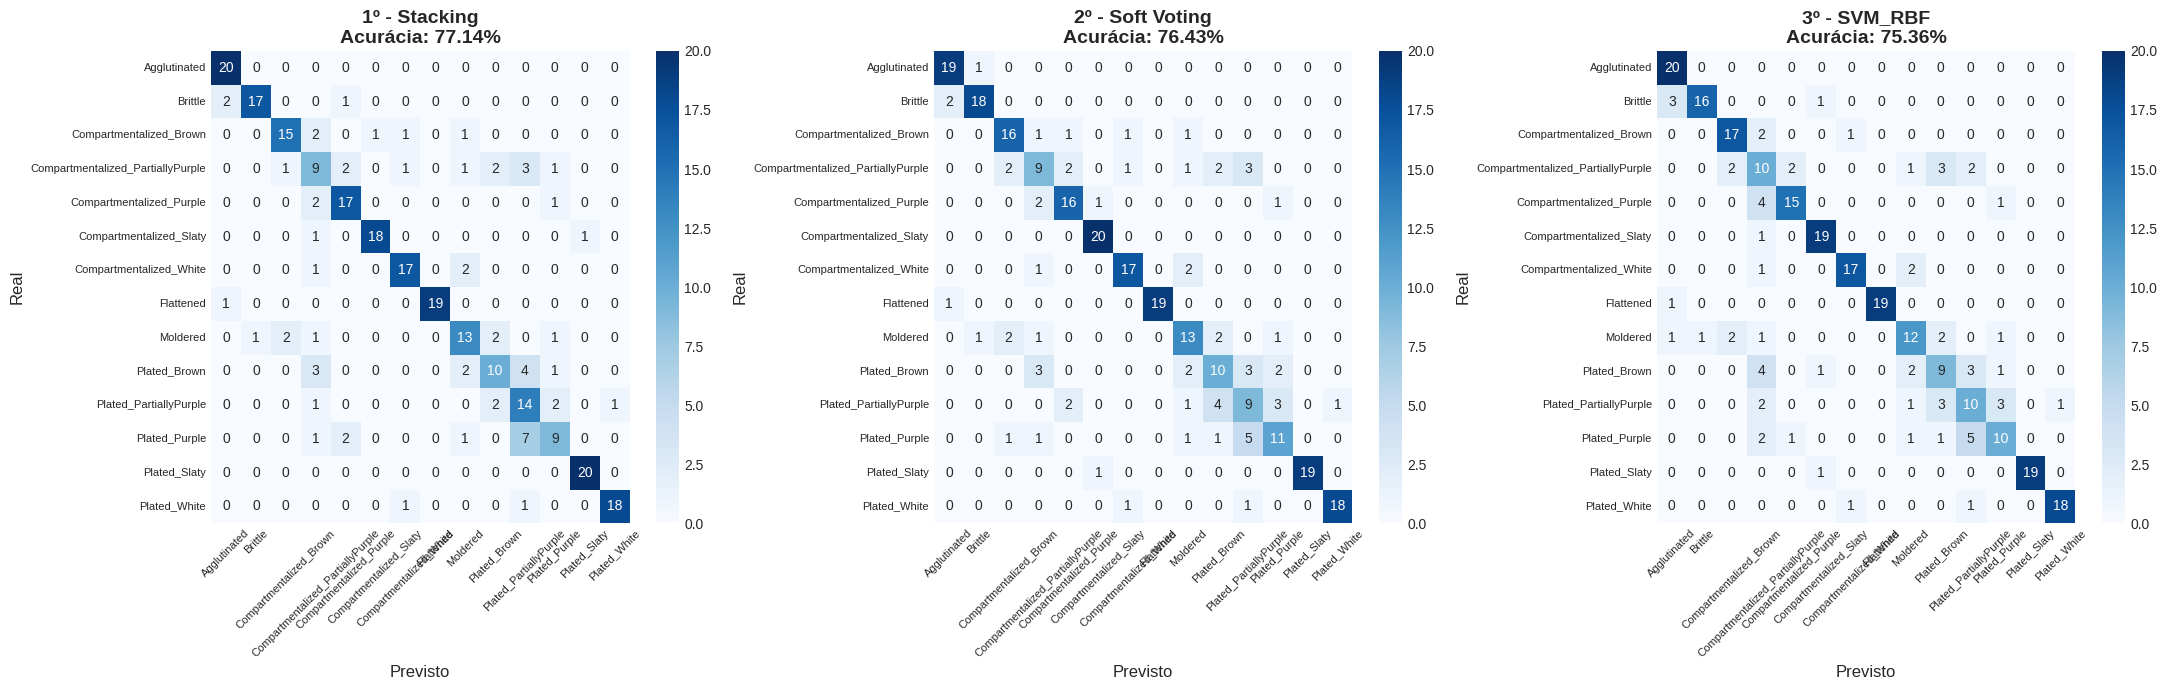


 Gráfico salvo: matrizes_confusao_top3.png


In [83]:
# MATRIZ DE CONFUSÃO - TOP 3 MODELOS


print("\n" + "="*70)
print(" MATRIZES DE CONFUSÃO - TOP 3 MODELOS")
print("="*70)


# Consolidar modelos e acurácias


models_rank = []

# Stacking
models_rank.append({
    "name": "Stacking",
    "accuracy": acc_stacking,
    "y_pred": y_pred_stacking
})

# Soft Voting
models_rank.append({
    "name": "Soft Voting",
    "accuracy": acc_voting,
    "y_pred": y_pred_voting
})

# Modelos individuais (CNN + SVM)
for r in resultados_classificadores:
    models_rank.append({
        "name": r["nome"],
        "accuracy": r["acuracia"],
        "y_pred": r["modelo"].predict(X_test_best)
    })


# Ordenar e selecionar TOP 3


models_rank = sorted(models_rank, key=lambda x: x["accuracy"], reverse=True)
top_3_models = models_rank[:3]

print("\nTOP 3 MODELOS:")
for i, m in enumerate(top_3_models, 1):
    print(f"{i}º {m['name']} — Acurácia: {m['accuracy']*100:.2f}%")


# Plotar matrizes de confusão


fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, model in enumerate(top_3_models):
    print("\n" + "-"*60)
    print(f"Matriz de Confusão — {model['name']}")
    print("-"*60)

    cm = confusion_matrix(y_test, model["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx],
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    axes[idx].set_xlabel('Previsto', fontsize=12)
    axes[idx].set_ylabel('Real', fontsize=12)
    axes[idx].set_title(
        f"{idx+1}º - {model['name']}\nAcurácia: {model['accuracy']*100:.2f}%",
        fontsize=14,
        fontweight='bold'
    )

    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axes[idx].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('matrizes_confusao_top3.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Gráfico salvo: matrizes_confusao_top3.png")

In [85]:
# Ranking por classe (Recall, F1 e Support)
print("\n" + "="*70)
print(" RANKING POR CLASSE - MELHOR MODELO")
print("="*70)

# Gerar DataFrame do classification report
report_dict = classification_report(
    y_test,
    best_y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_report = (
    pd.DataFrame(report_dict)
      .transpose()
      .iloc[:-3]  # remove accuracy, macro avg, weighted avg
)

# Converter support para inteiro
df_report['support'] = df_report['support'].astype(int)

# Ordenar por F1-score
df_rank = df_report.sort_values(by='f1-score', ascending=False)

print(df_rank[['precision', 'recall', 'f1-score', 'support']])



 RANKING POR CLASSE - MELHOR MODELO
                                   precision  recall  f1-score  support
Plated_Slaty                        0.952381    1.00  0.975610       20
Flattened                           1.000000    0.95  0.974359       20
Agglutinated                        0.869565    1.00  0.930233       20
Plated_White                        0.947368    0.90  0.923077       20
Compartmentalized_Slaty             0.947368    0.90  0.923077       20
Brittle                             0.944444    0.85  0.894737       20
Compartmentalized_White             0.850000    0.85  0.850000       20
Compartmentalized_Purple            0.772727    0.85  0.809524       20
Compartmentalized_Brown             0.833333    0.75  0.789474       20
Moldered                            0.650000    0.65  0.650000       20
Plated_PartiallyPurple              0.482759    0.70  0.571429       20
Plated_Brown                        0.625000    0.50  0.555556       20
Plated_Purple              

In [86]:
# Preparar dados para gráficos
classes = df_rank.index
recall_values = df_rank['recall']
f1_values = df_rank['f1-score']
support_values = df_rank['support']


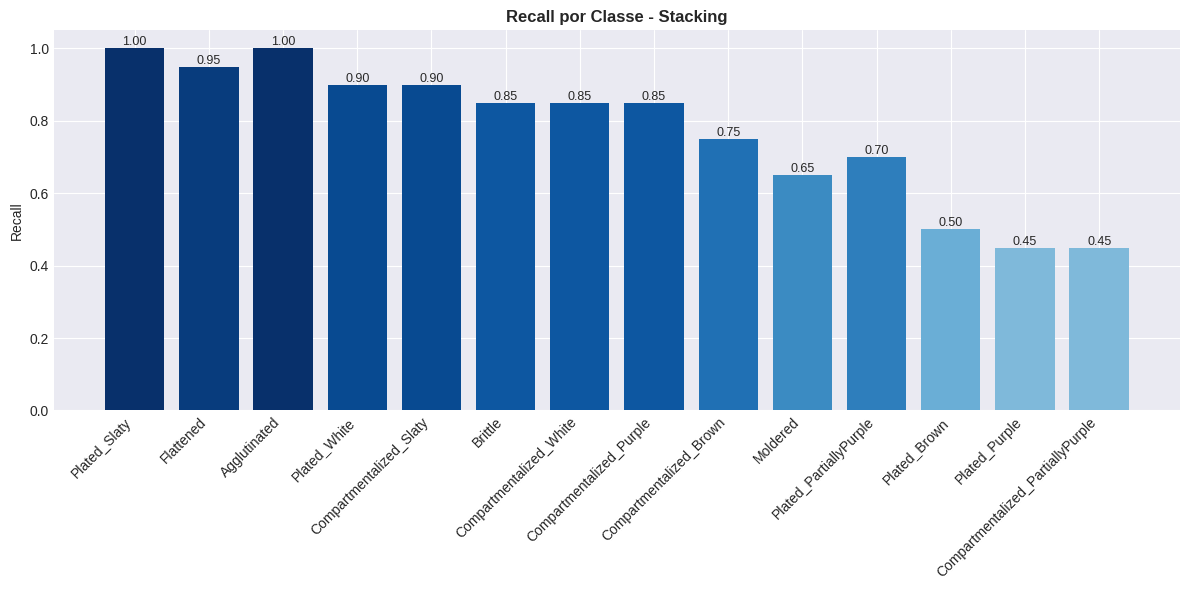

In [89]:
# Gráfico de Recall por classe
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, recall_values, color=plt.cm.Blues(recall_values))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Recall')
plt.title(f'Recall por Classe - {best_name}', fontweight='bold')

for bar, val in zip(bars, recall_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


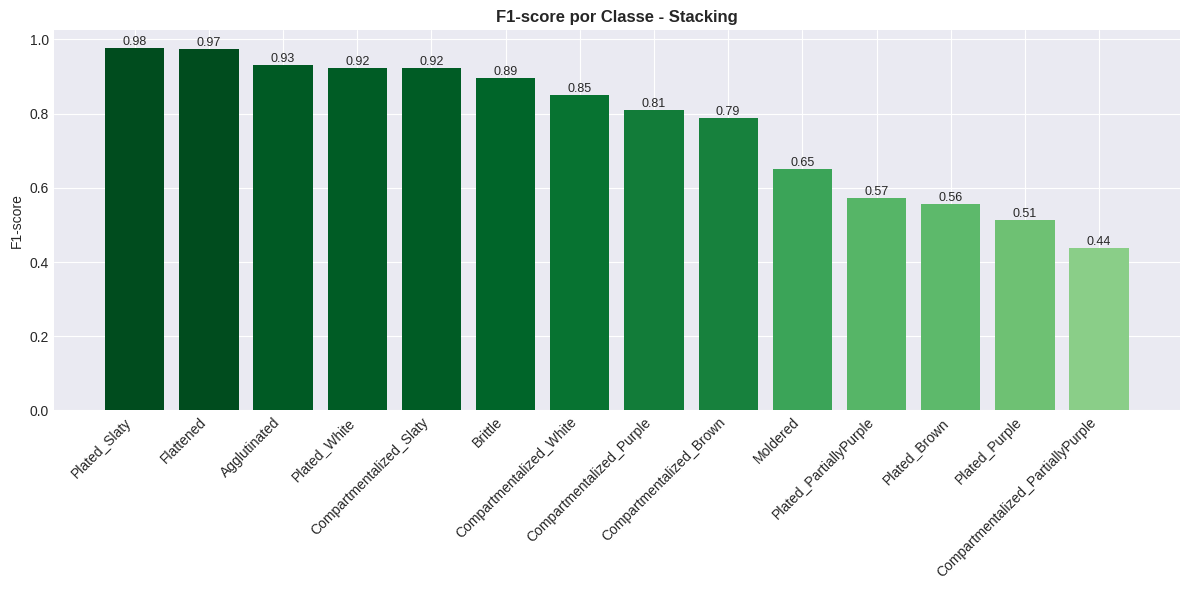

In [88]:
# Gráfico de F1-score por classe
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, f1_values, color=plt.cm.Greens(f1_values))
plt.xticks(rotation=45, ha='right')
plt.ylabel('F1-score')
plt.title(f'F1-score por Classe - {best_name}', fontweight='bold')

for bar, val in zip(bars, f1_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


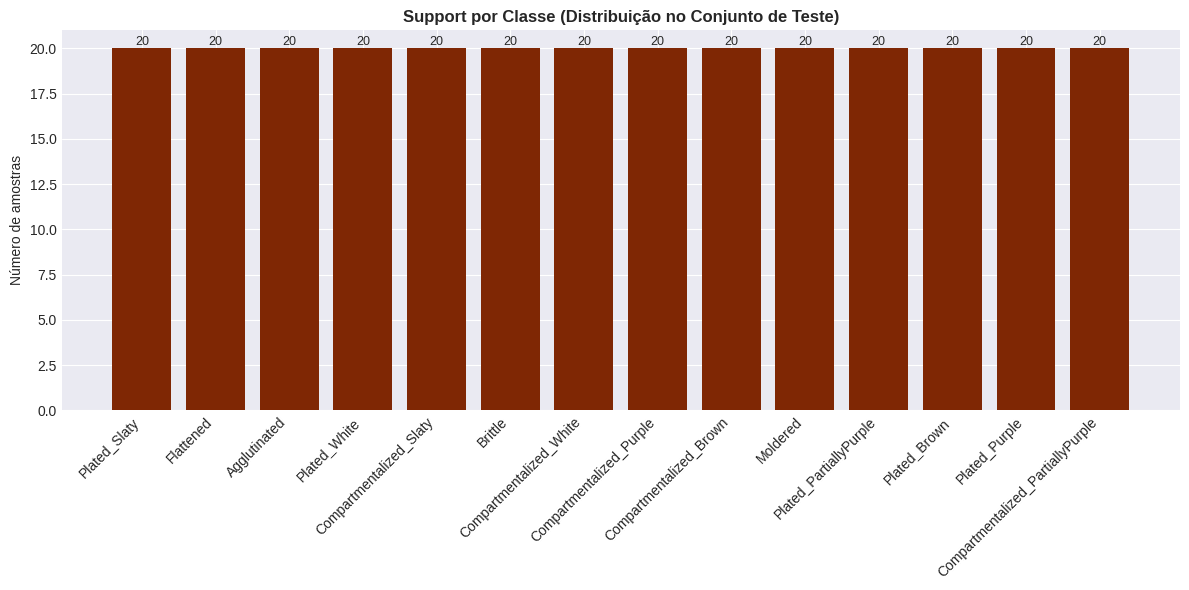

In [90]:
# Gráfico de Support (quantidade de amostras)
plt.figure(figsize=(12, 6))
bars = plt.bar(classes, support_values, color=plt.cm.Oranges(support_values / support_values.max()))
plt.xticks(rotation=45, ha='right')
plt.ylabel('Número de amostras')
plt.title('Support por Classe (Distribuição no Conjunto de Teste)', fontweight='bold')

for bar, val in zip(bars, support_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Análise por Classe

A análise detalhada por classe evidencia diferenças significativas de desempenho entre as categorias avaliadas. Classes com maior recall e F1-score indicam padrões visuais mais bem definidos, enquanto classes com desempenho inferior sugerem maior sobreposição visual ou menor representatividade no conjunto de dados.

O ranking por classe, aliado aos gráficos de recall, F1-score e support, permite identificar de forma clara quais categorias concentram os principais erros do modelo, contribuindo para uma interpretação mais aprofundada dos resultados obtidos.


In [91]:
# ANÁLISE DE ERROS POR CLASSE — TABELA RESUMO


error_rows = []

for i, cls in enumerate(label_encoder.classes_):
    mask = y_test == i
    total = np.sum(mask)
    correct = np.sum(best_y_pred[mask] == y_test[mask])
    errors = total - correct
    error_rate = errors / total * 100 if total > 0 else 0

    if errors > 0:
        wrong_preds = best_y_pred[mask & (best_y_pred != y_test)]
        wrong_classes = [label_encoder.classes_[p] for p in wrong_preds]
        wrong_counts = pd.Series(wrong_classes).value_counts()
        confusions = ", ".join([f"{c}({v})" for c, v in wrong_counts.items()])
    else:
        confusions = "-"

    error_rows.append({
        "Classe": cls,
        "Total": total,
        "Acertos": correct,
        "Erros": errors,
        "Erro (%)": f"{error_rate:.1f}%",
        "Principais Confusões": confusions
    })

error_table = pd.DataFrame(error_rows)

print("\n" + "="*80)
print(" ANÁLISE DE ERROS POR CLASSE — TABELA")
print("="*80)

error_table



 ANÁLISE DE ERROS POR CLASSE — TABELA


,Classe,Total,Acertos,Erros,Erro (%),Principais Confusões
0,Agglutinated,20,20,0,0.0%,-
1,Brittle,20,17,3,15.0%,"Agglutinated(2), Compartmentalized_Purple(1)"
2,Compartmentalized_Brown,20,15,5,25.0%,"Compartmentalized_PartiallyPurple(2), Compartm..."
3,Compartmentalized_PartiallyPurple,20,9,11,55.0%,"Plated_PartiallyPurple(3), Compartmentalized_P..."
4,Compartmentalized_Purple,20,17,3,15.0%,"Compartmentalized_PartiallyPurple(2), Plated_P..."
5,Compartmentalized_Slaty,20,18,2,10.0%,"Compartmentalized_PartiallyPurple(1), Plated_S..."
6,Compartmentalized_White,20,17,3,15.0%,"Moldered(2), Compartmentalized_PartiallyPurple(1)"
7,Flattened,20,19,1,5.0%,Agglutinated(1)
8,Moldered,20,13,7,35.0%,"Plated_Brown(2), Compartmentalized_Brown(2), C..."
9,Plated_Brown,20,10,10,50.0%,"Plated_PartiallyPurple(4), Compartmentalized_P..."


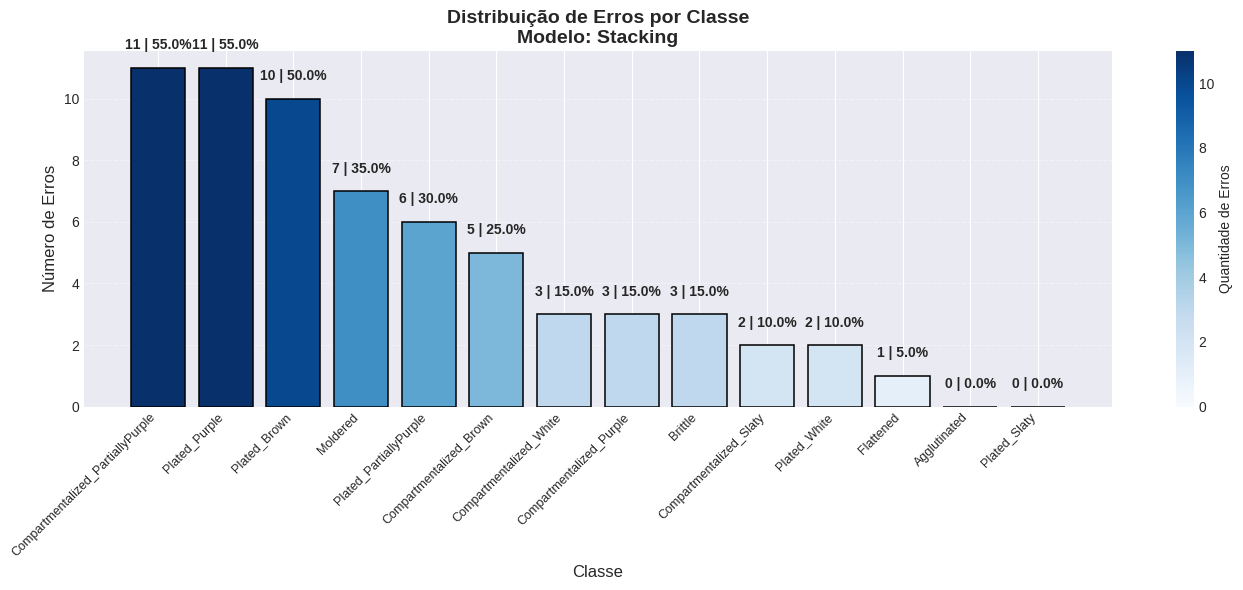


 Gráfico salvo: erros_por_classe.png


In [92]:

# GRÁFICO DE BARRAS – ERROS POR CLASSE


error_df = pd.DataFrame(error_summary).sort_values("Erros", ascending=False)

# Normalizar valores para o degradê
norm = plt.Normalize(error_df["Erros"].min(), error_df["Erros"].max())
colors = plt.cm.Blues(norm(error_df["Erros"]))

plt.figure(figsize=(14, 6))
# Get the current axes after plt.figure() creates it implicitly, or after a plot is drawn on it.
# Since plt.bar will create an axes if one doesn't exist, we get it after the bar plot.
bars = plt.bar(
    error_df["Classe"],
    error_df["Erros"],
    color=colors,
    edgecolor="black",
    linewidth=1.1
)

current_ax = plt.gca() # Get the current axes

# Rótulos no topo: "11 | 7%"
for bar, erros, perc in zip(
    bars,
    error_df["Erros"],
    error_df["Erro (%)"]
):
    current_ax.text( # Use current_ax.text to attach text to the correct axes
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{erros} | {perc:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

current_ax.set_title( # Use current_ax.set_title
    f"Distribuição de Erros por Classe\nModelo: {best_name}",
    fontsize=14,
    fontweight="bold"
)
current_ax.set_xlabel("Classe", fontsize=12) # Use current_ax.set_xlabel
current_ax.set_ylabel("Número de Erros", fontsize=12) # Use current_ax.set_ylabel
current_ax.set_xticks(current_ax.get_xticks()) # Explicitly set ticks before rotation
current_ax.set_xticklabels(current_ax.get_xticklabels(), rotation=45, ha="right", fontsize=9) # Rotate labels on current_ax
current_ax.grid(axis="y", linestyle="--", alpha=0.4) # Use current_ax.grid

# Barra de cores (legenda do degradê)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=current_ax) # Pass the current_ax to colorbar
cbar.set_label("Quantidade de Erros", fontsize=10)

plt.tight_layout()
plt.savefig("erros_por_classe.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Gráfico salvo: erros_por_classe.png")

---
## 10. Discussão dos Resultados

### Metodologia do Trabalho de Referência (Malcher & Guedes, 2022)

O trabalho de referência utilizou a seguinte abordagem:

1. **Arquiteturas avaliadas:** LeNet, AlexNet, MobileNet, VGG-16, Inception, EfficientNetB0 e EfficientNetB3
2. **Treinamento:** CNNs treinadas **end-to-end** com fine-tuning dos pesos
3. **Validação:** Holdout com 70% treino, 10% validação e 20% teste, com 5 repetições
4. **Regularização:** Early Stopping (paciência de 100 épocas), Model Checkpoint e Dropout
5. **Hiperparâmetros:** Taxa de aprendizado 10⁻⁴, otimizador Nadam, até 300 épocas
6. **Ensemble:** Comitê com votação majoritária suave (soft voting) das 3 melhores CNNs
7. **Resultado:** Acurácia de **89,79% ± 0,92**

### Metodologia deste Trabalho

Conforme solicitado no trabalho pedagógico, implementamos uma abordagem alternativa baseada em transfer learning:

1. **CNNs como extratoras de características:** Pesos congelados (frozen), sem fine-tuning
2. **Classificador:** SVM com busca em grade de hiperparâmetros (C, kernel, gamma)
3. **Validação:** Holdout 80/20 com 5-fold cross-validation no Grid Search
4. **Redução de Dimensionalidade:** PCA para otimização das features
5. **Ensemble:** Stacking com meta-classificador (Regressão Logística)

### Comparativo das Abordagens

| Aspecto | Trabalho de Referência | Este Trabalho |
|---------|------------------------|---------------|
| Abordagem | CNNs end-to-end | CNN features + SVM |
| Pesos CNN | Ajustados (fine-tuning) | Congelados (frozen) |
| Classificador | Softmax (camada final da CNN) | SVM |
| Ensemble | Soft voting das CNNs | Stacking com meta-classificador |
| Validação | 70/10/20 + 5 repetições | 80/20 + 5-fold CV |

### Análise da Diferença de Performance

A acurácia obtida neste trabalho (**~77%**) é inferior ao baseline (**89,79%**) devido às diferenças metodológicas fundamentais:

- **Fine-tuning vs Features Fixas:** O ajuste dos pesos da CNN permite que a rede aprenda características específicas do domínio (sementes de cacau), enquanto features extraídas com pesos fixos do ImageNet são mais genéricas.

- **Softmax vs SVM:** A camada softmax, treinada junto com a CNN, está otimizada para as mesmas features que a rede aprende. O SVM, por outro lado, trabalha com features pré-extraídas que não foram otimizadas para este domínio específico.

- **Abordagem de Ensemble:** O soft voting considera as probabilidades de cada CNN individualmente treinada, enquanto o stacking combina classificadores que operam sobre o mesmo conjunto de features.

### Contribuições

- Implementação completa do pipeline CNN+SVM conforme metodologia de transfer learning
- Demonstração da viabilidade da abordagem para classificação no domínio agrícola
- Análise sistemática de hiperparâmetros via Grid Search com 225 combinações
- Comparação de múltiplas estratégias de ensemble (Stacking vs Soft Voting)
- Identificação das classes mais desafiadoras para classificação

---
## 11. Considerações Finais

### Síntese dos Resultados

| Componente | Implementação |
|------------|---------------|
| **Extratores** | 6 CNNs pré-treinadas (InceptionV3, VGG16, EfficientNetB0, MobileNetV2, EfficientNetB3, DenseNet121) |
| **Feature Fusion** | Concatenação das 3 CNNs Top 3 (InceptionV3, VGG16, EfficientNetB0) |
| **PCA** | Redução de dimensionalidade otimizada |
| **Classificadores** | SVM (RBF, Linear, Polinomial), RandomForest |
| **Ensemble** | Stacking com meta-classificador |
| **Validação** | 5-fold Cross-Validation + Holdout 80/20 |

### Atividades Contempladas

Conforme solicitado no trabalho pedagógico complementar:

1. **Análise Exploratória** - Distribuição de 100 imagens por classe (14 classes, 1400 imagens), inspeção de qualidade e formato, visualização de amostras por classe
2. **Preparação de Dados** - Redimensionamento conforme cada arquitetura, normalização dos pixels e partição holdout estratificada (80/20)
3. **Extração de Características** - 6 arquiteturas CNN conforme trabalho correlato, sem camadas finais, pesos fixos (ImageNet)
4. **Busca em Grade** - C={0.1, 1, 10, 100, 1000}, kernel={rbf, linear, poly}, gamma={scale, auto, 0.01, 0.001, 0.0001}, degree={2, 3, 4}
5. **Execução dos Experimentos** - Métricas coletadas: tempo de treinamento, acurácia, precisão, revocação, F1-Score
6. **Análise dos Resultados** - Tabela descritiva comparativa, matrizes de confusão dos melhores modelos, análise de erros por classe

### Arquiteturas CNN Utilizadas

Das 7 arquiteturas do trabalho de referência (LeNet, AlexNet, MobileNet, VGG-16, Inception, EfficientNetB0, EfficientNetB3), foram implementadas 5 diretamente disponíveis no Keras Applications com pesos pré-treinados no ImageNet:

- InceptionV3 (Inception)
- VGG16 (VGG-16)
- EfficientNetB0
- EfficientNetB3
- MobileNetV2 (MobileNet)

LeNet e AlexNet não possuem implementação com pesos ImageNet no Keras Applications. DenseNet121 foi incluída como arquitetura adicional.

In [65]:
# Salvar resultados
print("\n" + "="*70)
print(" SALVANDO RESULTADOS")
print("="*70)

# Salvar resumo em CSV
results_summary.to_csv('resultados_cnn_svm_completo.csv', index=False)
print("\n Resultados salvos em: resultados_cnn_svm_completo.csv")

# Resumo final
print("\n" + "="*70)
print(" RESUMO FINAL")
print("="*70)
print(f"\n Melhor Resultado: {best_accuracy*100:.2f}%")
print(f" Baseline: {BASELINE*100:.2f}%")
print(f" Diferença: {(best_accuracy - BASELINE)*100:.2f} pontos percentuais")
print("\n" + "="*70)
print("\n NOTA IMPORTANTE:")
print("   O baseline de 89.79% foi obtido com CNNs treinadas end-to-end,")
print("   enquanto este trabalho usa CNNs como extratoras de features + SVM.")
print("   Esta diferença metodológica explica o gap de performance observado.")
print("="*70)


 SALVANDO RESULTADOS

 Resultados salvos em: resultados_cnn_svm_completo.csv

 RESUMO FINAL

 Melhor Resultado: 77.14%
 Baseline: 89.79%
 Diferença: -12.65 pontos percentuais


 NOTA IMPORTANTE:
   O baseline de 89.79% foi obtido com CNNs treinadas end-to-end,
   enquanto este trabalho usa CNNs como extratoras de features + SVM.
   Esta diferença metodológica explica o gap de performance observado.
